# Synthetic Mechanical Defect Dataset Generator

This notebook creates controlled mechanical defect images from clean normal
inspection images.

Supported defects:

- housing crack;
- oil leak;
- corrosion;
- surface wear;
- overheating discoloration.

Every generated anomaly has an exact binary mask, severity, seed, and source
image recorded in a CSV manifest. This makes the dataset suitable for DINOv2
anomaly detection and localization evaluation.

The generator modifies appearance only. It does not synthesize the underlying
robot or gearbox geometry.


## Expected Server Layout

Place normal images here:

```text
notebooks/data/synthetic_mechanical/source_normal/
  robot_joint_001.png
  gearbox_001.png
  bearing_001.png
```

When this notebook runs from `notebooks/vision/`, it writes:

```text
notebooks/data/synthetic_mechanical/generated/
  normal/
  anomaly/{crack,oil_leak,corrosion,wear,overheating}/
  masks/{crack,oil_leak,corrosion,wear,overheating}/
  manifest.csv
  generation_report.json
```


In [1]:
# Run only when packages are missing:
%pip install "numpy<2.3" "pandas<3" pillow opencv-python-headless matplotlib



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import hashlib
import json
import math
import random
import shutil
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

SEED = 42
VARIANTS_PER_DEFECT = 20
MIN_NORMAL_SOURCES_FOR_MODELING = 8
OUTPUT_SIZE = (1024, 1024)
DEFECT_TYPES = ("crack", "oil_leak", "corrosion", "wear", "overheating")
SEVERITIES = ("low", "medium", "high")
IMAGE_SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

DATA_ROOT = Path("/workspace/notebooks/data")
DATASET_ROOT = DATA_ROOT / "synthetic_mechanical"
SOURCE_DIR = DATASET_ROOT / "source_normal"
OUTPUT_ROOT = DATASET_ROOT / "generated"
NORMAL_DIR = OUTPUT_ROOT / "normal"
ANOMALY_ROOT = OUTPUT_ROOT / "anomaly"
MASK_ROOT = OUTPUT_ROOT / "masks"
COMPONENT_MASK_ROOT = OUTPUT_ROOT / "component_masks"

random.seed(SEED)
np.random.seed(SEED)

for path in (
    SOURCE_DIR,
    NORMAL_DIR,
    ANOMALY_ROOT,
    MASK_ROOT,
    COMPONENT_MASK_ROOT,
):
    path.mkdir(parents=True, exist_ok=True)
for defect_type in DEFECT_TYPES:
    (ANOMALY_ROOT / defect_type).mkdir(parents=True, exist_ok=True)
    (MASK_ROOT / defect_type).mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd().resolve())
print("Source normal directory:", SOURCE_DIR.resolve())
print("Generated dataset:", OUTPUT_ROOT.resolve())


Working directory: /workspace/notebooks/vision
Source normal directory: /workspace/notebooks/data/synthetic_mechanical/source_normal
Generated dataset: /workspace/notebooks/data/synthetic_mechanical/generated


## 1. Load and Normalize Source Images


In [3]:
def source_images():
    return sorted(
        path
        for path in SOURCE_DIR.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES
    )


def normalize_image(path: Path):
    image = Image.open(path).convert("RGB")
    image = image.resize(OUTPUT_SIZE, Image.Resampling.LANCZOS)
    return np.asarray(image)


sources = source_images()
if not sources:
    raise FileNotFoundError(
        f"No normal images found in {SOURCE_DIR.resolve()}. "
        "Upload clean robot-joint, gearbox, bearing, or motor images first."
    )

source_rows = []
for source_path in sources:
    normalized = normalize_image(source_path)
    output_name = f"{source_path.stem}_normal.png"
    output_path = NORMAL_DIR / output_name
    Image.fromarray(normalized).save(output_path)
    source_rows.append(
        {
            "source_path": source_path,
            "normal_path": output_path,
            "asset_type": source_path.stem.split("_")[0],
        }
    )

print("Normalized source images:", len(source_rows))
if len(source_rows) < MIN_NORMAL_SOURCES_FOR_MODELING:
    print(
        "WARNING: Generation can continue, but DINOv2 evaluation needs at "
        f"least {MIN_NORMAL_SOURCES_FOR_MODELING} distinct normal source images."
    )


Normalized source images: 2


## 2. Region Selection

Defects are placed inside an automatically estimated machine foreground mask
and a configurable region of interest (ROI). This prevents defects from being
drawn on the studio background. You can refine difficult images with
`ROI_OVERRIDES`.

Coordinates are normalized as `(x_min, y_min, x_max, y_max)`.


In [4]:
DEFAULT_ROI = (0.15, 0.15, 0.85, 0.85)

# Example:
# ROI_OVERRIDES = {
#     "robot_joint_001": (0.30, 0.20, 0.82, 0.78),
# }
ROI_OVERRIDES = {}


def pixel_roi(image, source_stem):
    height, width = image.shape[:2]
    x_min, y_min, x_max, y_max = ROI_OVERRIDES.get(
        source_stem,
        DEFAULT_ROI,
    )
    return (
        int(x_min * width),
        int(y_min * height),
        int(x_max * width),
        int(y_max * height),
    )


def estimate_component_mask(image, roi):
    height, width = image.shape[:2]
    x_min, y_min, x_max, y_max = roi
    grabcut_mask = np.zeros((height, width), dtype=np.uint8)
    background_model = np.zeros((1, 65), dtype=np.float64)
    foreground_model = np.zeros((1, 65), dtype=np.float64)
    rectangle = (
        max(1, x_min),
        max(1, y_min),
        max(2, x_max - x_min),
        max(2, y_max - y_min),
    )

    cv2.grabCut(
        image,
        grabcut_mask,
        rectangle,
        background_model,
        foreground_model,
        5,
        cv2.GC_INIT_WITH_RECT,
    )
    component = np.where(
        (grabcut_mask == cv2.GC_FGD)
        | (grabcut_mask == cv2.GC_PR_FGD),
        255,
        0,
    ).astype(np.uint8)

    roi_mask = np.zeros_like(component)
    roi_mask[y_min:y_max + 1, x_min:x_max + 1] = 255
    component = cv2.bitwise_and(component, roi_mask)
    component = cv2.morphologyEx(
        component,
        cv2.MORPH_CLOSE,
        np.ones((19, 19), dtype=np.uint8),
    )

    contours, _ = cv2.findContours(
        component,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
    if not contours:
        raise ValueError("Could not estimate a machine foreground mask.")

    # Keep all meaningful connected machine parts, including joints and cables.
    minimum_area = 0.002 * height * width
    cleaned = np.zeros_like(component)
    for contour in contours:
        if cv2.contourArea(contour) >= minimum_area:
            cv2.drawContours(cleaned, [contour], -1, 255, -1)

    if not np.any(cleaned):
        raise ValueError("Estimated machine foreground mask is empty.")
    return cleaned


def placement_mask(component_mask):
    # Keep defect centers away from component edges.
    eroded = cv2.erode(
        component_mask,
        np.ones((31, 31), dtype=np.uint8),
        iterations=1,
    )
    return eroded if np.any(eroded) else component_mask


def random_point(rng, roi, valid_mask):
    x_min, y_min, x_max, y_max = roi
    ys, xs = np.where(valid_mask > 0)
    inside = (
        (xs >= x_min)
        & (xs <= x_max)
        & (ys >= y_min)
        & (ys <= y_max)
    )
    xs = xs[inside]
    ys = ys[inside]
    if len(xs) == 0:
        raise ValueError("No valid foreground pixels are available in the ROI.")
    index = int(rng.integers(0, len(xs)))
    return int(xs[index]), int(ys[index])


def severity_scale(severity):
    return {"low": 0.65, "medium": 1.0, "high": 1.45}[severity]


## 3. Defect Rendering Functions


In [5]:
def apply_crack(image, rng, roi, valid_mask, severity):
    output = image.copy()
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    scale = severity_scale(severity)

    start = random_point(rng, roi, valid_mask)
    angle = rng.uniform(0, 2 * math.pi)
    length = int(rng.integers(100, 190) * scale)
    segments = int(rng.integers(5, 9))
    thickness = max(2, int(round(2.5 * scale)))

    points = [start]
    current = np.array(start, dtype=float)
    for _ in range(segments):
        angle += rng.normal(0, 0.35)
        step = length / segments * rng.uniform(0.8, 1.2)
        current += np.array([math.cos(angle), math.sin(angle)]) * step
        current[0] = np.clip(current[0], roi[0], roi[2])
        current[1] = np.clip(current[1], roi[1], roi[3])
        points.append(tuple(current.astype(int)))

    cv2.polylines(mask, [np.array(points)], False, 255, thickness * 3)
    cv2.polylines(output, [np.array(points)], False, (25, 25, 28), thickness)

    # Add one or two short branches.
    for branch_index in rng.choice(
        np.arange(1, len(points) - 1),
        size=min(2, len(points) - 2),
        replace=False,
    ):
        branch_start = np.array(points[branch_index])
        branch_angle = angle + rng.choice([-1, 1]) * rng.uniform(0.7, 1.2)
        branch_length = int(length * rng.uniform(0.12, 0.25))
        branch_end = branch_start + np.array(
            [math.cos(branch_angle), math.sin(branch_angle)]
        ) * branch_length
        branch_end = branch_end.astype(int)
        cv2.line(
            mask,
            tuple(branch_start),
            tuple(branch_end),
            255,
            thickness * 2,
        )
        cv2.line(
            output,
            tuple(branch_start),
            tuple(branch_end),
            (30, 30, 32),
            max(1, thickness - 1),
        )

    return output, mask


def apply_oil_leak(image, rng, roi, valid_mask, severity):
    output = image.copy()
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    scale = severity_scale(severity)
    center = random_point(rng, roi, valid_mask)
    axes = (
        int(rng.integers(35, 70) * scale),
        int(rng.integers(55, 110) * scale),
    )
    angle = float(rng.uniform(0, 180))

    cv2.ellipse(mask, center, axes, angle, 0, 360, 255, -1)

    # Add the gravity-driven trail before rendering so image and mask agree.
    trail_end = (
        center[0] + int(rng.normal(0, 10)),
        min(image.shape[0] - 1, center[1] + int(axes[1] * 1.6)),
    )
    cv2.line(mask, center, trail_end, 255, max(5, int(10 * scale)))

    blur_size = max(9, int(25 * scale) | 1)
    soft_mask = cv2.GaussianBlur(mask, (blur_size, blur_size), 0) / 255.0
    oil_color = np.array([35, 28, 18], dtype=np.float32)
    alpha = (0.35 + 0.2 * scale) * soft_mask[..., None]
    output = (
        output.astype(np.float32) * (1 - alpha)
        + oil_color * alpha
    ).clip(0, 255).astype(np.uint8)

    return output, mask


def apply_corrosion(image, rng, roi, valid_mask, severity):
    output = image.copy()
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    scale = severity_scale(severity)
    center = random_point(rng, roi, valid_mask)
    radius = int(rng.integers(45, 85) * scale)

    for _ in range(int(45 * scale)):
        angle = rng.uniform(0, 2 * math.pi)
        distance = radius * math.sqrt(rng.random())
        point = (
            int(center[0] + math.cos(angle) * distance),
            int(center[1] + math.sin(angle) * distance),
        )
        spot_radius = int(rng.integers(3, 12) * scale)
        color = (
            int(rng.integers(45, 85)),
            int(rng.integers(70, 115)),
            int(rng.integers(120, 180)),
        )
        cv2.circle(output, point, spot_radius, color, -1)
        cv2.circle(mask, point, spot_radius + 2, 255, -1)

    return output, mask


def apply_wear(image, rng, roi, valid_mask, severity):
    output = image.copy()
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    scale = severity_scale(severity)
    center = random_point(rng, roi, valid_mask)
    width = int(rng.integers(100, 180) * scale)
    height = int(rng.integers(25, 55) * scale)
    angle = float(rng.uniform(0, 180))

    cv2.ellipse(mask, center, (width, height), angle, 0, 360, 255, -1)
    texture = rng.normal(0, 18 * scale, image.shape).astype(np.float32)
    lightened = np.clip(
        image.astype(np.float32) + 30 + texture,
        0,
        255,
    ).astype(np.uint8)
    alpha = cv2.GaussianBlur(mask, (17, 17), 0)[..., None] / 255.0
    output = (
        output.astype(np.float32) * (1 - 0.55 * alpha)
        + lightened.astype(np.float32) * (0.55 * alpha)
    ).clip(0, 255).astype(np.uint8)

    return output, mask


def apply_overheating(image, rng, roi, valid_mask, severity):
    output = image.copy()
    mask = np.zeros(image.shape[:2], dtype=np.uint8)
    scale = severity_scale(severity)
    center = random_point(rng, roi, valid_mask)
    axes = (
        int(rng.integers(55, 100) * scale),
        int(rng.integers(55, 100) * scale),
    )
    cv2.ellipse(mask, center, axes, 0, 0, 360, 255, -1)
    soft_mask = cv2.GaussianBlur(mask, (61, 61), 0) / 255.0

    heat_color = np.array([55, 85, 150], dtype=np.float32)
    alpha = (0.22 + 0.12 * scale) * soft_mask[..., None]
    output = (
        output.astype(np.float32) * (1 - alpha)
        + heat_color * alpha
    ).clip(0, 255).astype(np.uint8)

    return output, mask


DEFECT_FUNCTIONS = {
    "crack": apply_crack,
    "oil_leak": apply_oil_leak,
    "corrosion": apply_corrosion,
    "wear": apply_wear,
    "overheating": apply_overheating,
}


## 4. Generate Images, Masks, and Manifest


In [6]:
def deterministic_seed(source_name, defect_type, variant):
    value = f"{SEED}:{source_name}:{defect_type}:{variant}".encode()
    return int(hashlib.sha256(value).hexdigest()[:8], 16)


manifest_rows = []
total_anomalies = (
    len(source_rows) * len(DEFECT_FUNCTIONS) * VARIANTS_PER_DEFECT
)
completed_anomalies = 0
generation_started = time.perf_counter()

print(
    f"Starting generation: {len(source_rows)} sources, "
    f"{len(DEFECT_FUNCTIONS)} defect types, "
    f"{total_anomalies} anomaly images",
    flush=True,
)

for source_index, source_row in enumerate(source_rows, start=1):
    source_path = source_row["source_path"]
    normal_path = source_row["normal_path"]
    source_stem = source_path.stem
    print(
        f"\n[{source_index}/{len(source_rows)}] Loading {source_path.name}",
        flush=True,
    )
    image = np.asarray(Image.open(normal_path).convert("RGB"))
    roi = pixel_roi(image, source_stem)
    print("  Detecting machine foreground...", flush=True)
    component_mask = estimate_component_mask(image, roi)
    valid_placement_mask = placement_mask(component_mask)
    component_mask_path = COMPONENT_MASK_ROOT / f"{source_stem}.png"
    Image.fromarray(component_mask).save(component_mask_path)
    print("  Foreground ready.", flush=True)

    manifest_rows.append(
        {
            "sample_id": f"{source_stem}_normal",
            "asset_type": source_row["asset_type"],
            "label": "normal",
            "defect_type": "none",
            "severity": "none",
            "source_image": source_path.name,
            "image_path": normal_path.relative_to(OUTPUT_ROOT).as_posix(),
            "mask_path": "",
            "seed": SEED,
            "synthetic": True,
        }
    )

    for defect_type, defect_function in DEFECT_FUNCTIONS.items():
        defect_started = time.perf_counter()
        print(
            f"  Generating {defect_type}: "
            f"0/{VARIANTS_PER_DEFECT}",
            end="",
            flush=True,
        )
        for variant in range(VARIANTS_PER_DEFECT):
            variant_seed = deterministic_seed(
                source_stem,
                defect_type,
                variant,
            )
            rng = np.random.default_rng(variant_seed)
            severity = SEVERITIES[variant % len(SEVERITIES)]
            defective, mask = defect_function(
                image,
                rng,
                roi,
                valid_placement_mask,
                severity,
            )
            mask = cv2.bitwise_and(mask, component_mask)
            defective = np.where(
                component_mask[..., None] > 0,
                defective,
                image,
            )

            sample_id = f"{source_stem}_{defect_type}_{variant:03d}"
            anomaly_path = (
                ANOMALY_ROOT / defect_type / f"{sample_id}.png"
            )
            mask_path = MASK_ROOT / defect_type / f"{sample_id}_mask.png"

            Image.fromarray(defective).save(anomaly_path)
            Image.fromarray(mask).save(mask_path)
            completed_anomalies += 1

            manifest_rows.append(
                {
                    "sample_id": sample_id,
                    "asset_type": source_row["asset_type"],
                    "label": "anomaly",
                    "defect_type": defect_type,
                    "severity": severity,
                    "source_image": source_path.name,
                    "image_path": anomaly_path.relative_to(
                        OUTPUT_ROOT
                    ).as_posix(),
                    "mask_path": mask_path.relative_to(
                        OUTPUT_ROOT
                    ).as_posix(),
                    "seed": variant_seed,
                    "synthetic": True,
                }
            )

            progress_interval = max(1, VARIANTS_PER_DEFECT // 4)
            if (
                (variant + 1) % progress_interval == 0
                or variant + 1 == VARIANTS_PER_DEFECT
            ):
                elapsed = time.perf_counter() - generation_started
                rate = completed_anomalies / max(elapsed, 1e-9)
                remaining = total_anomalies - completed_anomalies
                eta = remaining / max(rate, 1e-9)
                print(
                    f"\r  Generating {defect_type}: "
                    f"{variant + 1}/{VARIANTS_PER_DEFECT} | "
                    f"overall {completed_anomalies}/{total_anomalies} | "
                    f"ETA {eta:.1f}s",
                    end="",
                    flush=True,
                )

        defect_elapsed = time.perf_counter() - defect_started
        print(f" | done in {defect_elapsed:.1f}s", flush=True)

manifest = pd.DataFrame(manifest_rows)
manifest_path = OUTPUT_ROOT / "manifest.csv"
manifest.to_csv(manifest_path, index=False)
total_elapsed = time.perf_counter() - generation_started

display(
    manifest.groupby(["label", "defect_type", "severity"])
    .size()
    .to_frame("count")
)
print("Saved manifest:", manifest_path.resolve())
print(f"Generation completed in {total_elapsed:.1f}s", flush=True)


Starting generation: 2 sources, 5 defect types, 200 anomaly images

[1/2] Loading Generated image 1.png
  Detecting machine foreground...
  Foreground ready.
  Generating crack: 20/20 | overall 20/200 | ETA 228.9s | done in 8.6s
  Generating oil_leak: 20/20 | overall 40/200 | ETA 139.9s | done in 9.5s
  Generating corrosion: 20/20 | overall 60/200 | ETA 101.6s | done in 8.6s
  Generating wear: 20/20 | overall 80/200 | ETA 81.0s | done in 10.4s
  Generating overheating: 20/20 | overall 100/200 | ETA 63.6s | done in 9.7s

[2/2] Loading Generated image 2.png
  Detecting machine foreground...
  Foreground ready.
  Generating crack: 20/20 | overall 120/200 | ETA 60.1s | done in 9.3s
  Generating oil_leak: 20/20 | overall 140/200 | ETA 43.0s | done in 10.2s
  Generating corrosion: 20/20 | overall 160/200 | ETA 27.4s | done in 9.3s
  Generating wear: 20/20 | overall 180/200 | ETA 13.4s | done in 11.1s
  Generating overheating: 20/20 | overall 200/200 | ETA 0.0s | done in 10.4s


count
label   defect_type severity       
anomaly corrosion   high         12
                    low          14
                    medium       14
        crack       high         12
                    low          14
                    medium       14
        oil_leak    high         12
                    low          14
                    medium       14
        overheating high         12
                    low          14
                    medium       14
        wear        high         12
                    low          14
                    medium       14
normal  none        none          2

Saved manifest: /workspace/notebooks/data/synthetic_mechanical/generated/manifest.csv
Generation completed in 131.1s


## 5. Validate Generated Images and Masks


In [7]:
validation_rows = []
anomaly_rows = manifest[manifest["label"] == "anomaly"]
total_validation = len(anomaly_rows)
validation_started = time.perf_counter()

print(f"Starting validation of {total_validation} anomalies...", flush=True)

for index, (_, row) in enumerate(anomaly_rows.iterrows(), start=1):
    image_path = OUTPUT_ROOT / row["image_path"]
    mask_path = OUTPUT_ROOT / row["mask_path"]

    image = np.asarray(Image.open(image_path).convert("RGB"))
    mask = np.asarray(Image.open(mask_path).convert("L"))
    source_stem = Path(row["source_image"]).stem
    component_mask_path = COMPONENT_MASK_ROOT / f"{source_stem}.png"
    if not component_mask_path.is_file():
        raise FileNotFoundError(
            f"Missing saved component mask: {component_mask_path}. "
            "Rerun the generation cell first."
        )
    component_mask = np.asarray(
        Image.open(component_mask_path).convert("L")
    )
    outside_component_pixels = int(
        ((mask > 0) & (component_mask == 0)).sum()
    )

    validation_rows.append(
        {
            "sample_id": row["sample_id"],
            "image_exists": image_path.is_file(),
            "mask_exists": mask_path.is_file(),
            "matching_size": image.shape[:2] == mask.shape[:2],
            "mask_pixels": int((mask > 0).sum()),
            "mask_binary": set(np.unique(mask)).issubset({0, 255}),
            "outside_component_pixels": outside_component_pixels,
        }
    )

    progress_interval = max(1, total_validation // 8)
    if index % progress_interval == 0 or index == total_validation:
        elapsed = time.perf_counter() - validation_started
        rate = index / max(elapsed, 1e-9)
        eta = (total_validation - index) / max(rate, 1e-9)
        print(
            f"Validated {index}/{total_validation} | ETA {eta:.1f}s",
            flush=True,
        )

validation = pd.DataFrame(validation_rows)
invalid = validation[
    (~validation["image_exists"])
    | (~validation["mask_exists"])
    | (~validation["matching_size"])
    | (~validation["mask_binary"])
    | (validation["mask_pixels"] == 0)
    | (validation["outside_component_pixels"] > 0)
]

print("Generated anomaly samples:", len(validation))
print("Invalid samples:", len(invalid))
print(
    f"Validation completed in "
    f"{time.perf_counter() - validation_started:.1f}s"
)
display(validation.describe(include="all"))

if len(invalid):
    display(invalid.head())
    raise ValueError("Generated dataset validation failed.")


Starting validation of 200 anomalies...
Validated 25/200 | ETA 7.7s
Validated 50/200 | ETA 6.6s
Validated 75/200 | ETA 5.5s
Validated 100/200 | ETA 4.4s
Validated 125/200 | ETA 3.3s
Validated 150/200 | ETA 2.2s
Validated 175/200 | ETA 1.1s
Validated 200/200 | ETA 0.0s
Generated anomaly samples: 200
Invalid samples: 0
Validation completed in 8.7s


,sample_id,image_exists,mask_exists,matching_size,mask_pixels,mask_binary,outside_component_pixels
count,200,200,200,200,200.000000,200,200.0
unique,200,1,1,1,NaN,1,NaN
top,Generated image 1_crack_000,True,True,True,NaN,True,NaN
freq,1,200,200,200,NaN,200,NaN
mean,NaN,NaN,NaN,NaN,12229.215000,NaN,0.0
std,NaN,NaN,NaN,NaN,10941.817988,NaN,0.0
min,NaN,NaN,NaN,NaN,252.000000,NaN,0.0
25%,NaN,NaN,NaN,NaN,3249.000000,NaN,0.0
50%,NaN,NaN,NaN,NaN,8805.500000,NaN,0.0
75%,NaN,NaN,NaN,NaN,18883.750000,NaN,0.0


In [8]:
print("Total invalid:", len(invalid))

checks = {
    "missing_image": ~validation["image_exists"],
    "missing_mask": ~validation["mask_exists"],
    "size_mismatch": ~validation["matching_size"],
    "non_binary_mask": ~validation["mask_binary"],
    "empty_mask": validation["mask_pixels"] == 0,
    "outside_component": validation["outside_component_pixels"] > 0,
}

for name, failed in checks.items():
    print(f"{name}: {int(failed.sum())}")

display(
    validation.loc[
        validation["outside_component_pixels"] > 0,
        ["sample_id", "mask_pixels", "outside_component_pixels"],
    ].head(20)
)

Total invalid: 0
missing_image: 0
missing_mask: 0
size_mismatch: 0
non_binary_mask: 0
empty_mask: 0
outside_component: 0


,sample_id,mask_pixels,outside_component_pixels


In [9]:
validation["outside_ratio"] = (
    validation["outside_component_pixels"]
    / validation["mask_pixels"].clip(lower=1)
)

invalid = validation[
    (~validation["image_exists"])
    | (~validation["mask_exists"])
    | (~validation["matching_size"])
    | (~validation["mask_binary"])
    | (validation["mask_pixels"] == 0)
    | (validation["outside_ratio"] > 0.01)
]

print("Invalid after 1% tolerance:", len(invalid))

Invalid after 1% tolerance: 0


In [10]:
invalid_ids = set(invalid["sample_id"])

clean_manifest = manifest[
    ~manifest["sample_id"].isin(invalid_ids)
].copy()

clean_manifest.to_csv(
    OUTPUT_ROOT / "manifest_validated.csv",
    index=False,
)

print("Original records:", len(manifest))
print("Removed anomalies:", len(invalid_ids))
print("Validated records:", len(clean_manifest))

Original records: 202
Removed anomalies: 0
Validated records: 202


In [11]:
bad = validation[
    validation["outside_ratio"] > 0.01
].copy()

bad["outside_percent"] = bad["outside_ratio"] * 100

display(
    bad[
        ["sample_id", "mask_pixels",
         "outside_component_pixels", "outside_percent"]
    ].sort_values("outside_percent", ascending=False)
)

,sample_id,mask_pixels,outside_component_pixels,outside_percent


In [12]:
bad_details = bad.merge(
    manifest[["sample_id", "defect_type", "source_image"]],
    on="sample_id",
)

display(
    bad_details.groupby(
        ["source_image", "defect_type"]
    ).size().to_frame("failed_count")
)

,,failed_count
source_image,defect_type,


## 6. Visual Review


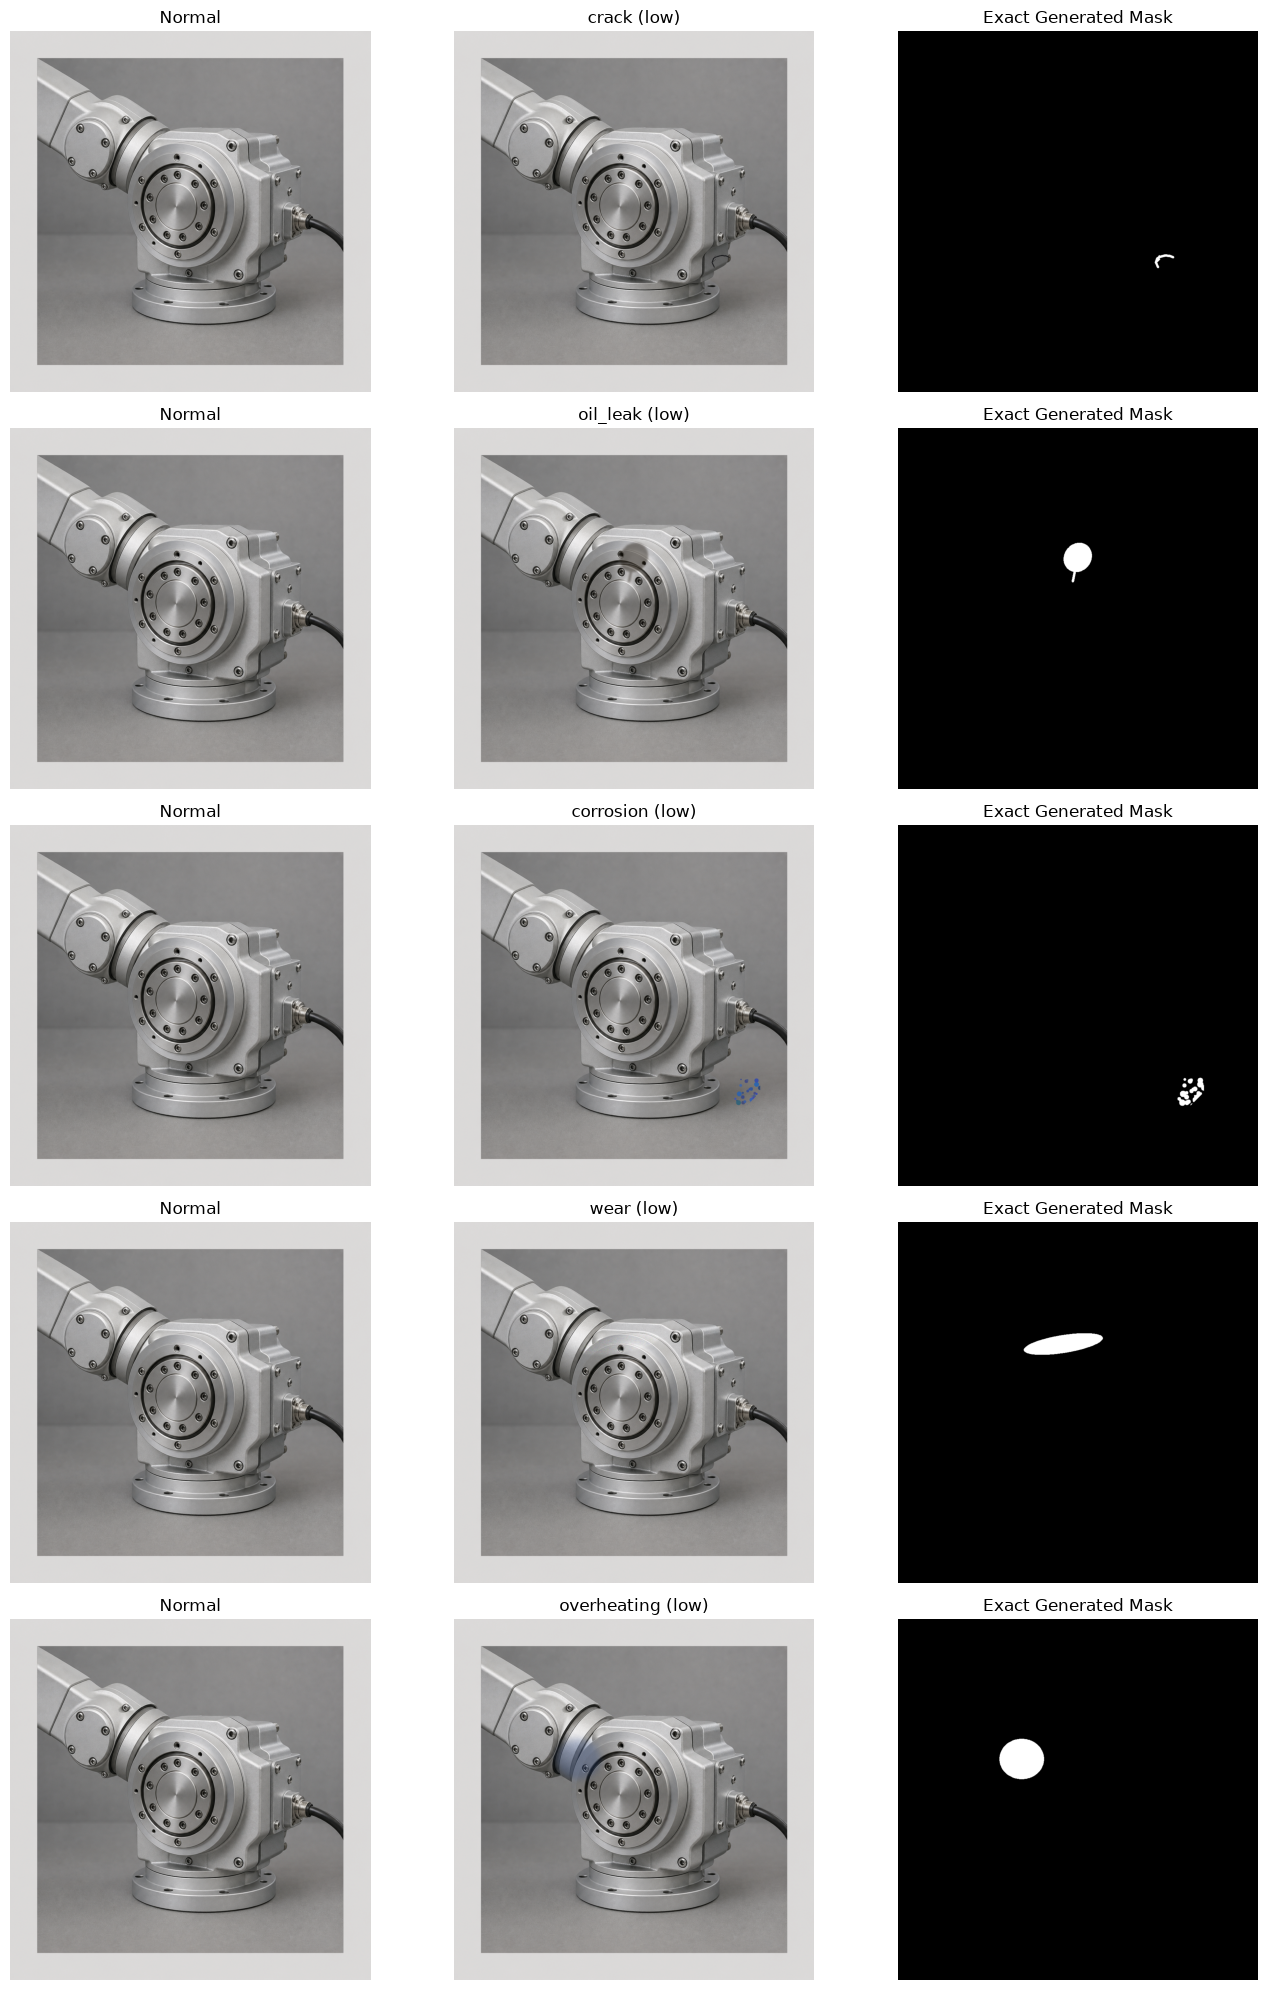

In [13]:
examples = (
    manifest[manifest["label"] == "anomaly"]
    .groupby("defect_type", group_keys=False)
    .head(1)
)

fig, axes = plt.subplots(len(examples), 3, figsize=(14, 4 * len(examples)))

for row_index, (_, row) in enumerate(examples.iterrows()):
    normal_name = f"{Path(row['source_image']).stem}_normal.png"
    normal = Image.open(NORMAL_DIR / normal_name).convert("RGB")
    anomaly = Image.open(OUTPUT_ROOT / row["image_path"]).convert("RGB")
    mask = Image.open(OUTPUT_ROOT / row["mask_path"]).convert("L")

    axes[row_index, 0].imshow(normal)
    axes[row_index, 0].set_title("Normal")
    axes[row_index, 1].imshow(anomaly)
    axes[row_index, 1].set_title(
        f"{row['defect_type']} ({row['severity']})"
    )
    axes[row_index, 2].imshow(mask, cmap="gray")
    axes[row_index, 2].set_title("Exact Generated Mask")

    for axis in axes[row_index]:
        axis.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "dataset_preview.png", dpi=150)
plt.show()


## 7. Save Dataset Report


In [14]:
report = {
    "dataset": "Synthetic Mechanical Defects",
    "generator_version": "0.2.0",
    "seed": SEED,
    "output_size": list(OUTPUT_SIZE),
    "source_normal_images": len(source_rows),
    "minimum_normal_sources_for_modeling": MIN_NORMAL_SOURCES_FOR_MODELING,
    "variants_per_defect_per_source": VARIANTS_PER_DEFECT,
    "defect_types": list(DEFECT_TYPES),
    "normal_samples": int((manifest["label"] == "normal").sum()),
    "anomaly_samples": int((manifest["label"] == "anomaly").sum()),
    "invalid_samples": int(len(invalid)),
    "limitations": [
        "Defects are programmatic overlays on clean inspection images.",
        "The dataset validates system behavior but does not replace real factory images.",
        "ROI settings should be reviewed for every new source image.",
    ],
}

report_path = OUTPUT_ROOT / "generation_report.json"
report_path.write_text(json.dumps(report, indent=2), encoding="utf-8")

print(json.dumps(report, indent=2))
print("Dataset root:", OUTPUT_ROOT.resolve())


{
  "dataset": "Synthetic Mechanical Defects",
  "generator_version": "0.2.0",
  "seed": 42,
  "output_size": [
    1024,
    1024
  ],
  "source_normal_images": 2,
  "minimum_normal_sources_for_modeling": 8,
  "variants_per_defect_per_source": 20,
  "defect_types": [
    "crack",
    "oil_leak",
    "corrosion",
    "wear",
    "overheating"
  ],
  "normal_samples": 2,
  "anomaly_samples": 200,
  "invalid_samples": 0,
  "limitations": [
    "Defects are programmatic overlays on clean inspection images.",
    "The dataset validates system behavior but does not replace real factory images.",
    "ROI settings should be reviewed for every new source image."
  ]
}
Dataset root: /workspace/notebooks/data/synthetic_mechanical/generated


## Recommended First Run

Start with:

```python
VARIANTS_PER_DEFECT = 20
```

For three normal source images and five defect types, this produces:

```text
3 normal images
300 anomaly images
300 exact masks
```

After visually reviewing placement and realism, increase to 50-100 variants per
defect. Keep the seed fixed for reproducibility.

The next step is adapting the DINOv2 notebook to read
`generated/manifest.csv` and train a class-specific normal memory bank.
